In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import pennylane as qml
from pennylane import numpy as np
from pennylane.optimize import NesterovMomentumOptimizer
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from pennylane.optimize import AdamOptimizer
from pennylane import numpy as pnp

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
print(df.shape)
df.head()


(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
'''print(data.target_names)
print(df['target'].value_counts())'''


"print(data.target_names)\nprint(df['target'].value_counts())"

In [3]:
'''print(df.isnull().sum().sum())'''

'print(df.isnull().sum().sum())'

In [4]:
'''print(data.feature_names)
df.describe()'''

'print(data.feature_names)\ndf.describe()'

In [5]:
'''malignant = df[df['target'] == 0]['mean radius']
benign = df[df['target'] == 1]['mean radius']

plt.hist(malignant, bins=30, alpha=0.5, label='malignant', color='red')
plt.hist(benign, bins=30, alpha=0.5, label='benign', color='green')
plt.legend()
plt.xlabel('mean radius')
plt.show()'''
                        

"malignant = df[df['target'] == 0]['mean radius']\nbenign = df[df['target'] == 1]['mean radius']\n\nplt.hist(malignant, bins=30, alpha=0.5, label='malignant', color='red')\nplt.hist(benign, bins=30, alpha=0.5, label='benign', color='green')\nplt.legend()\nplt.xlabel('mean radius')\nplt.show()"

In [6]:
'''corr = df.drop('target', axis=1).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='RdYlGn', center=0)
plt.show()'''

"corr = df.drop('target', axis=1).corr()\nplt.figure(figsize=(12, 10))\nsns.heatmap(corr, cmap='RdYlGn', center=0)\nplt.show()"

In [7]:
scaler = StandardScaler()
X = df.drop('target', axis=1).values
y = df['target'].values

X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
print(f"Total variance kept: {pca.explained_variance_ratio_.sum()*100:.1f}%")

[0.44272026 0.18971182 0.09393163 0.06602135]
Total variance kept: 79.2%


In [8]:
n_layers = 2
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

weights_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
weights = np.random.uniform(0, np.pi, weights_shape)

x = np.random.uniform(0, np.pi, n_qubits)

In [9]:
data = load_breast_cancer()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)

@qml.qnode(dev)
def full_pipeline(x, weights):
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))
print(full_pipeline(x, weights))

def classifier(weights, bias, x):
    return full_pipeline(x, weights) + bias

def square_loss(labels, predictions):
    preds = qml.math.stack(predictions)
    return qml.math.sum((labels - preds) ** 2) / len(labels)

def cost(weights, bias, X, y):
    preds = [classifier(weights, bias, x) for x in X]
    return square_loss(y, preds)

def accuracy(labels, weights, bias, X):
    preds = np.sign(np.array([float(classifier(weights, bias, x)) for x in X]))
    return np.mean(np.array(labels) == preds)

label = 1.0
prediction = 0.40

opt = AdamOptimizer(stepsize=0.1)
weights = pnp.random.uniform(0, pnp.pi, weights_shape, requires_grad=True)
bias = pnp.array(0.0, requires_grad=True)

print(weights.shape)
print(bias)

X_sample = pnp.array(X_train[:5], requires_grad=False)
y_sample = pnp.array(y_train[:5], requires_grad=False)
print(cost(weights, bias, X_sample, y_sample))

(455, 4)
(114, 4)
0.35077314726747605
(2, 4, 3)
0.0
0.8829430538052042


In [10]:
#STRONGLY ENTANGLING LAYERS
import numpy as np
X_tr = pnp.array(X_train, requires_grad=False)
Y_tr = pnp.array(2 * y_train - 1, requires_grad=False)
X_te = pnp.array(X_test, requires_grad=False)
Y_te = pnp.array(2 * y_test - 1, requires_grad=False)

n_layers = 15
strong_accs = []
strong_best_acc = []
strong_costs = []
strong_best_cost = []
weights_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)

pnp.random.seed(42)
weights = pnp.array(np.random.uniform(0, np.pi, weights_shape), requires_grad=True)
bias = pnp.array(0.0, requires_grad=True)
opt = AdamOptimizer(0.1)

batch_size = 15
n_epochs = 15
best_acc = 0.0
best_cost = 0.0

for epoch in range(n_epochs):
    idx = pnp.random.randint(0, len(X_tr), (batch_size,))
    result = opt.step(cost, weights, bias, X_tr[idx], Y_tr[idx])
    weights, bias = result[0], result[1]
    c = cost(weights, bias, X_tr, Y_tr)
    strong_costs.append(c)
    acc = accuracy(Y_te, weights, bias, X_te)
    strong_accs.append(acc)
    print(f"Epoch {epoch+1:3d} | Cost: {c:.4f} | Test Acc: {acc*100:.1f}% | Bias: {bias:.4f}")
    #print(f"{weights.reshape(24, 5)}")
    if acc > best_acc:
        best_acc = acc
    if c < best_cost or best_cost == 0.0:
        best_cost = c
print(f"Best Test Accuracy: {best_acc*100:.1f}%")
print(f"Best Test Cost: {best_cost:.4f}")
a_best_acc = best_acc
a_best_cost = best_cost
strong_best_acc.append(best_acc)
strong_best_cost.append(best_cost)

drawing_weights = weights.reshape(n_layers, n_qubits, 3)
'''fig, ax = qml.draw_mpl(full_pipeline)(X_te, drawing_weights)
plt.show()'''

Epoch   1 | Cost: 1.0597 | Test Acc: 49.1% | Bias: 0.1000
Epoch   2 | Cost: 0.9096 | Test Acc: 49.1% | Bias: 0.1983
Epoch   3 | Cost: 0.8607 | Test Acc: 63.2% | Bias: 0.2543
Epoch   4 | Cost: 0.8425 | Test Acc: 62.3% | Bias: 0.3133
Epoch   5 | Cost: 0.8758 | Test Acc: 65.8% | Bias: 0.3379
Epoch   6 | Cost: 0.9172 | Test Acc: 60.5% | Bias: 0.3455
Epoch   7 | Cost: 0.9362 | Test Acc: 55.3% | Bias: 0.3454
Epoch   8 | Cost: 0.9198 | Test Acc: 62.3% | Bias: 0.3772
Epoch   9 | Cost: 0.9132 | Test Acc: 61.4% | Bias: 0.3986
Epoch  10 | Cost: 0.8699 | Test Acc: 62.3% | Bias: 0.3683
Epoch  11 | Cost: 0.8584 | Test Acc: 61.4% | Bias: 0.3484
Epoch  12 | Cost: 0.8649 | Test Acc: 58.8% | Bias: 0.3145
Epoch  13 | Cost: 0.8761 | Test Acc: 58.8% | Bias: 0.2826
Epoch  14 | Cost: 0.8795 | Test Acc: 56.1% | Bias: 0.2801
Epoch  15 | Cost: 0.8603 | Test Acc: 57.0% | Bias: 0.2744
Best Test Accuracy: 65.8%
Best Test Cost: 0.8425


'fig, ax = qml.draw_mpl(full_pipeline)(X_te, drawing_weights)\nplt.show()'

In [11]:
#BASIC ENTANGLEMENT
@qml.qnode(dev)
def full_pipeline(x, weights):
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

X_tr = pnp.array(X_train, requires_grad=False)
Y_tr = pnp.array(2 * y_train - 1, requires_grad=False)
X_te = pnp.array(X_test, requires_grad=False)
Y_te = pnp.array(2 * y_test - 1, requires_grad=False)

n_layers = 15
weights_shape = qml.BasicEntanglerLayers.shape(n_layers=n_layers, n_wires=n_qubits)

pnp.random.seed(42)
weights = pnp.array(np.random.uniform(0, np.pi, weights_shape), requires_grad=True)
bias = pnp.array(0.0, requires_grad=True)
opt = AdamOptimizer(0.1)

batch_size = 15
basic_accs = []
basic_best_acc = []
basic_costs = []
basic_best_cost = []
n_epochs = 15
best_acc = 0.0
best_cost = 0.0

for epoch in range(n_epochs):
    idx = pnp.random.randint(0, len(X_tr), (batch_size,))
    result = opt.step(cost, weights, bias, X_tr[idx], Y_tr[idx])
    weights, bias = result[0], result[1]
    c = cost(weights, bias, X_tr, Y_tr)
    basic_costs.append(c)
    acc = accuracy(Y_te, weights, bias, X_te)
    basic_accs.append(acc)
    print(f"Epoch {epoch+1:3d} | Cost: {c:.4f} | Test Acc: {acc*100:.1f}% | Bias: {bias:.4f}")
    #print(f"{weights.reshape(8, 5)}")
    if acc > best_acc:
        best_acc = acc
    if c < best_cost or best_cost == 0.0:
        best_cost = c

print(f"Best Test Accuracy: {best_acc*100:.1f}%")
print(f"Best Test Cost: {best_cost:.4f}")
b_best_acc = best_acc
b_best_cost = best_cost
basic_best_acc.append(best_acc)
basic_best_cost.append(best_cost)

#basic_weights = weights.reshape(n_layers, n_qubits, 4)
#print("Basic Entangling Graph:")
#print(qml.draw(full_pipeline)(X_te, basic_weights))

Epoch   1 | Cost: 1.1483 | Test Acc: 50.0% | Bias: 0.1000
Epoch   2 | Cost: 1.0876 | Test Acc: 53.5% | Bias: 0.1894
Epoch   3 | Cost: 1.0235 | Test Acc: 58.8% | Bias: 0.2507
Epoch   4 | Cost: 1.0269 | Test Acc: 58.8% | Bias: 0.2872
Epoch   5 | Cost: 1.0228 | Test Acc: 59.6% | Bias: 0.3038
Epoch   6 | Cost: 1.0434 | Test Acc: 58.8% | Bias: 0.3430
Epoch   7 | Cost: 1.0485 | Test Acc: 57.9% | Bias: 0.3457
Epoch   8 | Cost: 1.0873 | Test Acc: 57.0% | Bias: 0.3412
Epoch   9 | Cost: 1.0927 | Test Acc: 56.1% | Bias: 0.3502
Epoch  10 | Cost: 1.0949 | Test Acc: 52.6% | Bias: 0.3140
Epoch  11 | Cost: 1.0965 | Test Acc: 52.6% | Bias: 0.2966
Epoch  12 | Cost: 1.0708 | Test Acc: 51.8% | Bias: 0.2729
Epoch  13 | Cost: 1.0562 | Test Acc: 53.5% | Bias: 0.2429
Epoch  14 | Cost: 1.0157 | Test Acc: 50.9% | Bias: 0.2092
Epoch  15 | Cost: 0.9832 | Test Acc: 50.0% | Bias: 0.1891
Best Test Accuracy: 59.6%
Best Test Cost: 0.9832


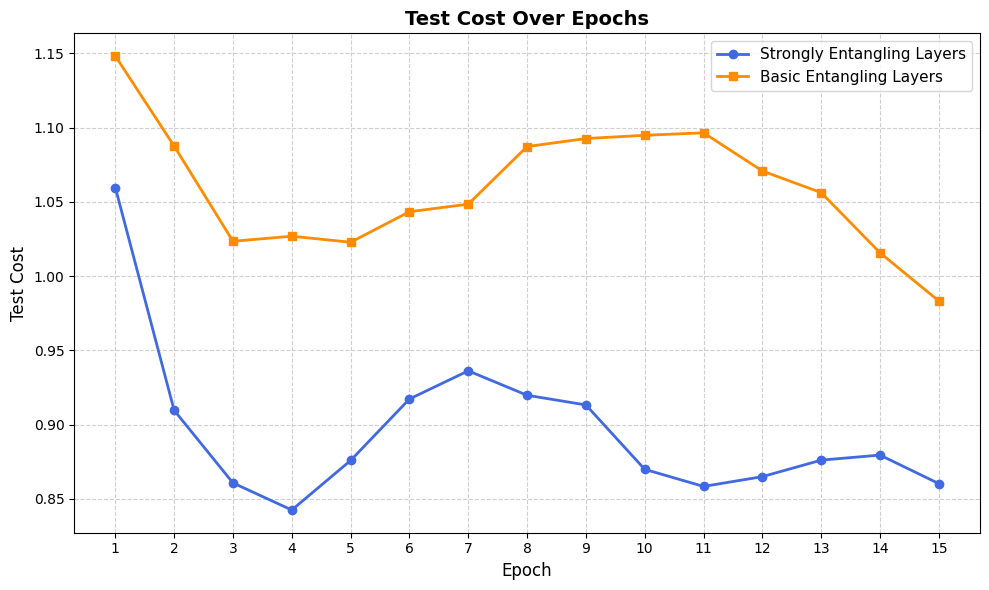

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

# Use the pre-existing lists tracking accuracy history
epochs = range(1, len(strong_accs) + 1)
ax.plot(epochs, strong_costs, marker='o', linewidth=2, label='Strongly Entangling Layers', color='royalblue')
ax.plot(epochs, basic_costs, marker='s', linewidth=2, label='Basic Entangling Layers', color='darkorange')

# Formatting the plot
ax.set_title('Test Cost Over Epochs', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Test Cost', fontsize=12)

# Ensure the x-axis displays integer ticks for each epoch (e.g., 1, 2, 3)
ax.set_xticks(epochs)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

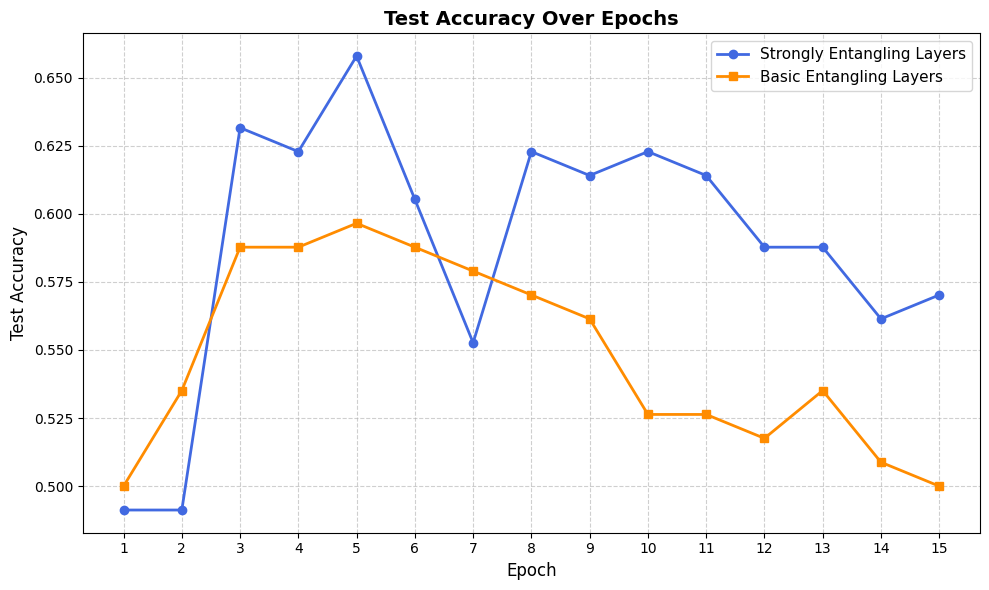

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

# Use the pre-existing lists tracking accuracy history
epochs = range(1, len(strong_accs) + 1)
ax.plot(epochs, strong_accs, marker='o', linewidth=2, label='Strongly Entangling Layers', color='royalblue')
ax.plot(epochs, basic_accs, marker='s', linewidth=2, label='Basic Entangling Layers', color='darkorange')

# Formatting the plot
ax.set_title('Test Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)

# Ensure the x-axis displays integer ticks for each epoch (e.g., 1, 2, 3)
ax.set_xticks(epochs)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

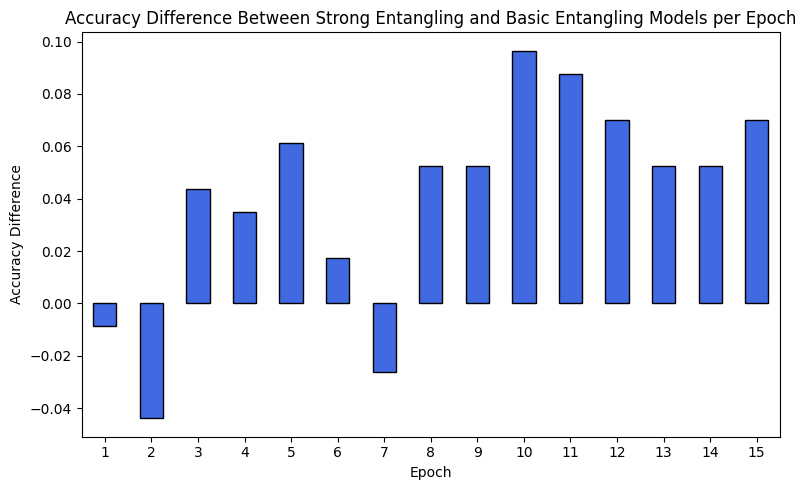

In [14]:
acc_diff = pd.Series(np.array(strong_accs) - np.array(basic_accs))

fig, ax = plt.subplots(figsize=(8, 5))
acc_diff.plot(kind='bar', ax=ax, color='royalblue', edgecolor='black')

ax.set_title('Accuracy Difference Between Strong Entangling and Basic Entangling Models per Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy Difference')

# Change x-axis labels from 0,1,2,3,4 to 1,2,3,4,5
ax.set_xticklabels([f"{i+1}" for i in range(len(acc_diff))], rotation=0)

plt.tight_layout()
plt.show()